# Comparison of Bisection and Newton-Raphson Methods

In this notebook, we simplify and compare two popular root-finding algorithms:
1. **Bisection Method**: A bracketed method that is robust and guarantees convergence, but typically converges slowly.
2. **Newton-Raphson Method**: An open method that uses the derivative of the function. It converges very fast but may fail if the initial guess is far from the root or if the derivative is zero.

We will use both methods to find the root of the function $f(x) = x^3 - 2x - 5$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Define the function and its derivative
def f(x):
    return x**3 - 2*x - 5

def df(x):
    return 3*x**2 - 2

### 1. Bisection Method
The Bisection method requires two initial guesses, $a$ and $b$, such that $f(a)$ and $f(b)$ have opposite signs. It repeatedly bisects the interval and selects the sub-interval that contains the root.

In [5]:
def bisection_method(f, a, b, tol=1e-6, max_iter=100):
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")
    
    errors = []
    start_time = time.perf_counter()
    
    for n in range(max_iter):
        c = (a + b) / 2
        error = abs(f(c))
        errors.append(error)
        
        if error < tol or (b - a) / 2 < tol:
            break
            
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
            
    end_time = time.perf_counter()
    execution_time = end_time - start_time
    
    return c, errors, execution_time

### 2. Newton-Raphson Method
The Newton-Raphson method takes a single initial guess $x_0$ and uses the tangent line to find the next approximation: $x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$.

In [6]:
def newton_raphson_method(f, df, x0, tol=1e-6, max_iter=100):
    errors = []
    xn = x0
    start_time = time.perf_counter()
    
    for n in range(max_iter):
        error = abs(f(xn))
        errors.append(error)
        
        if error < tol:
            break
            
        df_xn = df(xn)
        if df_xn == 0:
            print("Derivative is zero. Stopping.")
            break
            
        xn = xn - f(xn) / df_xn
        
    end_time = time.perf_counter()
    execution_time = end_time - start_time
    
    return xn, errors, execution_time

### 3. Running the Algorithms
Let's run both algorithms and compare their outputs. We will use the interval $[2, 3]$ for the Bisection method, and the initial guess $x_0 = 3$ for the Newton-Raphson method.

In [7]:
# Run Bisection
root_bisect, errors_bisect, time_bisect = bisection_method(f, 2.0, 3.0)

# Run Newton-Raphson
root_newton, errors_newton, time_newton = newton_raphson_method(f, df, 3.0)

print("=== Bisection Method ===")
print(f"Root Found: {root_bisect:.6f}")
print(f"Number of Iterations: {len(errors_bisect)}")
print(f"Execution Time: {time_bisect*1000:.4f} ms\n")

print("=== Newton-Raphson Method ===")
print(f"Root Found: {root_newton:.6f}")
print(f"Number of Iterations: {len(errors_newton)}")
print(f"Execution Time: {time_newton*1000:.4f} ms")

=== Bisection Method ===
Root Found: 2.094552
Number of Iterations: 20
Execution Time: 0.0705 ms

=== Newton-Raphson Method ===
Root Found: 2.094551
Number of Iterations: 6
Execution Time: 0.0246 ms


### 4. Visualization of Convergence
Let's visualize the error at each iteration. Notice how much steeper the curve is for the Newton-Raphson method, highlighting its faster quadratic convergence compared to the linear convergence of the Bisection method.

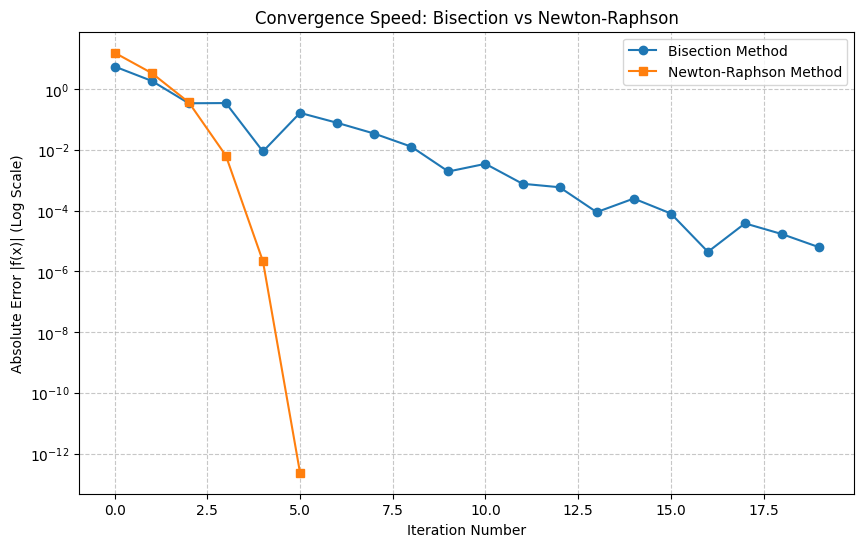

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(errors_bisect, label='Bisection Method', marker='o')
plt.plot(errors_newton, label='Newton-Raphson Method', marker='s')
plt.yscale('log')  # Log scale makes it easier to see convergence speeds
plt.xlabel('Iteration Number')
plt.ylabel('Absolute Error |f(x)| (Log Scale)')
plt.title('Convergence Speed: Bisection vs Newton-Raphson')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 5. Conclusion

Based on our results and the convergence graph, we can draw the following conclusions:

1. **Execution Time & Iterations**: The Newton-Raphson method reaches the desired tolerance ($10^{-6}$) in significantly fewer iterations and typically in less time than the Bisection method.
2. **Rate of Convergence**: The downward slope in the log-scale plot illustrates that Newton-Raphson features rapid *quadratic convergence*. The error shrinks enormously at each step once close to the root. In contrast, Bisection has a steady but slower *linear convergence*.
3. **Trade-offs**: 
   - **Newton-Raphson** is highly efficient but requires an analytically known derivative $f'(x)$ and a reasonably close initial guess to prevent divergence.
   - **Bisection** is extremely robust—guaranteed to find a root if given a bracket $[a, b]$ where the function changes signs—but it trades off this reliability for a slower convergence speed.